In [30]:
from pathlib import Path
import sys
import importlib
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=3, suppress=True, linewidth=120)
%matplotlib widget

repo_root = Path.cwd()
if not (repo_root / 'scripts').is_dir():
    repo_root = repo_root.parent
scripts_dir = repo_root / 'scripts'
sys.path.insert(0, str(scripts_dir))

import sector_calibrator
importlib.reload(sector_calibrator)
from sector_calibrator import (
    SectorCalibrator,
    SolveOptions,
    load_sector_directory,
    save_calibration_transform
)


In [31]:
data_dir = scripts_dir / 'data' / 'magacc_pitch' / 'readings_32'
use_streaming_input = True
max_sectors = None

weights = {
    'pitch_weight': 1.0,
    'perp_weight': 1.0,
    'norm_weight': 1.0,
    'dot_weight': 1.0,
    'prior_weight': 1e-8,
}

solver_options = SolveOptions(
    **weights,
    max_iters=60,
    lm_lambda0=1e-3,
)

print(f'data directory: {data_dir}')
print(f'input mode: {"streaming" if use_streaming_input else "batch"}')

data directory: c:\Users\vivia\Documents\PlatformIO\Projects\moonlight-260709-esp32dev\scripts\data\magacc_pitch\readings_32
input mode: streaming


In [32]:
all_sectors = load_sector_directory(data_dir)
sectors = all_sectors if max_sectors is None else all_sectors[:max_sectors]
print(f'loaded {len(sectors)} sectors')
print('samples per sector:', [len(sector[0]) for sector in sectors])

loaded 14 sectors
samples per sector: [500, 500, 121, 500, 500, 500, 500, 500, 131, 295, 224, 500, 500, 500]


In [33]:
calibrator = SectorCalibrator()

if use_streaming_input:
    for mag, acc, gyro, dt in sectors:
        for index in range(len(mag)):
            accepted, finished = calibrator.ingest(
                mag[index],
                acc[index],
                gyro=gyro[index],
                dt=dt[index],
                start_sector=(index == 0),
                end_sector=(index == len(mag) - 1),
            )
            if not accepted:
                raise ValueError(f'rejected sample {index}')
        if not finished:
            raise ValueError('sector did not finalize')
else:
    for mag, acc, gyro, dt in sectors:
        if not calibrator.add_sector(mag, acc, gyro=gyro, dt=dt):
            raise ValueError('sector did not finalize')

print(f'accepted samples: {calibrator.norm_count}')
print(f'finalized sectors: {len(calibrator.sectors)}')

accepted samples: 5771
finalized sectors: 14


In [34]:
result = calibrator.solve(solver_options, use_ellipsoid_init=True)
W_optimized = result.W

print('W =')
print(W_optimized)
print('bias =', result.bias)
print('dot target c =', result.c)
print('cost =', result.cost)
print('iterations =', result.iterations)
print('converged =', result.converged)
print('diagnostics =', calibrator.diagnostics(W_optimized))

W =
[[ 0.022  0.     0.    -0.39 ]
 [ 0.     0.017  0.004 -0.04 ]
 [-0.    -0.001  0.015 -0.29 ]]
bias = [17.895 -1.899 18.615]
dot target c = 0.8931400701876605
cost = 32.6115745953717
iterations = 8
converged = True
diagnostics = {'norm_squared_mean': 0.9910352792830376, 'norm_squared_rms_residual': 0.08140983063787002, 'dot_mean': 0.8931400701876496, 'dot_rms_residual': 0.031206460923935232}


In [35]:
irls_result = calibrator.solve_irls(
    sectors,
    solver_options,
    outer_iters=4,
    use_ellipsoid_init=True,
)
W_irls = irls_result.W
print('IRLS W =')
print(W_irls)
print('IRLS bias =', irls_result.bias)
print('IRLS cost =', irls_result.cost)
print('IRLS iterations =', irls_result.iterations)
print('IRLS converged =', irls_result.converged)
print('IRLS diagnostics =', calibrator.diagnostics(W_irls))


IRLS W =
[[ 0.022  0.     0.    -0.391]
 [ 0.     0.017  0.004 -0.04 ]
 [ 0.    -0.001  0.015 -0.291]]
IRLS bias = [17.933 -1.967 18.674]
IRLS cost = 32.631544674053494
IRLS iterations = 1
IRLS converged = True
IRLS diagnostics = {'norm_squared_mean': 0.9910250325223401, 'norm_squared_rms_residual': 0.0814931549856466, 'dot_mean': 0.9056458192519982, 'dot_rms_residual': 0.03122514158268756}


In [36]:
diagonal_result = calibrator.solve_diagonal(
    solver_options,
    use_ellipsoid_init=True,
)
W_diagonal = diagonal_result.W
print('diagonal + bias W =')
print(W_diagonal)
print('diagonal bias =', diagonal_result.bias)
print('diagonal cost =', diagonal_result.cost)
print('diagonal iterations =', diagonal_result.iterations)
print('diagonal converged =', diagonal_result.converged)


diagonal + bias W =
[[ 0.023  0.     0.    -0.411]
 [ 0.     0.019  0.     0.247]
 [ 0.     0.     0.016 -0.324]]
diagonal bias = [ 17.742 -12.674  20.454]
diagonal cost = 44.21975861296165
diagonal iterations = 10
diagonal converged = True


In [37]:
result = irls_result
W_optimized = result.W
# save_calibration_transform(W_optimized, result.c)

In [38]:
from sector_calibrator import calibrated_sector_objectives

objective_rows = []
for mag, acc, _, _ in sectors:
    values = calibrated_sector_objectives(W_optimized, mag, acc, result.c)
    objective_rows.append({
        "norm_mse": float(np.mean(values["norm_residual"]**2)),
        "dot_mse": float(np.mean(values["dot_residual"]**2)),
        "perpendicular_energy": float(
            np.mean(np.sum(values["perpendicular"]**2, axis=1))
        ),
    })

for index, row in enumerate(objective_rows):
    print(index, row)


0 {'norm_mse': 0.0042039357218911985, 'dot_mse': 0.0013299110725715855, 'perpendicular_energy': 0.20497952892686344}
1 {'norm_mse': 0.0025871328441448003, 'dot_mse': 0.00027145404203923854, 'perpendicular_energy': 0.23426304312135804}
2 {'norm_mse': 0.02178949240908913, 'dot_mse': 0.0008314721110812686, 'perpendicular_energy': 0.10290401888843043}
3 {'norm_mse': 0.016608740115817384, 'dot_mse': 0.0011707212255741535, 'perpendicular_energy': 0.096426241713045}
4 {'norm_mse': 0.006121824444885856, 'dot_mse': 0.000408109800656418, 'perpendicular_energy': 0.13534860164616874}
5 {'norm_mse': 0.0012781991066940451, 'dot_mse': 0.00047132599497876234, 'perpendicular_energy': 0.21131750821185322}
6 {'norm_mse': 0.00490897905947831, 'dot_mse': 0.0007048214691090628, 'perpendicular_energy': 0.29419873441899375}
7 {'norm_mse': 0.0040251913642591905, 'dot_mse': 0.0010795987272706833, 'perpendicular_energy': 0.30336192611940965}
8 {'norm_mse': 0.008787078787839957, 'dot_mse': 0.0007726615193954382, 

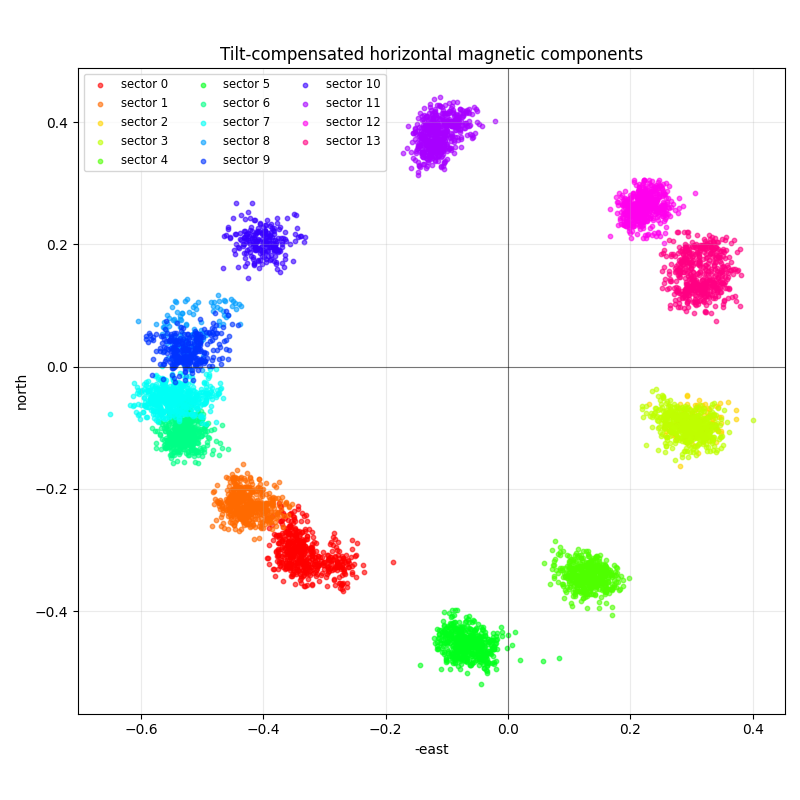

In [39]:
from sector_calibrator import tilt_compensated_horizontal_components

fig, ax = plt.subplots(figsize=(8, 8))
colors = plt.cm.hsv(np.linspace(0.0, 1.0, len(sectors), endpoint=False))
for index, (mag, acc, _, _) in enumerate(sectors):
    y = mag @ W_optimized[:, :3].T + W_optimized[:, 3]
    west, north = tilt_compensated_horizontal_components(y, acc)
    ax.scatter(west, north, s=10, alpha=0.6,
               color=colors[index], label=f"sector {index}")
ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
ax.axvline(0.0, color="black", linewidth=0.8, alpha=0.5)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("-east")
ax.set_ylabel("north")
ax.set_title("Tilt-compensated horizontal magnetic components")
ax.grid(alpha=0.25)
ax.legend(ncol=3, fontsize="small")
plt.tight_layout()
plt.show()


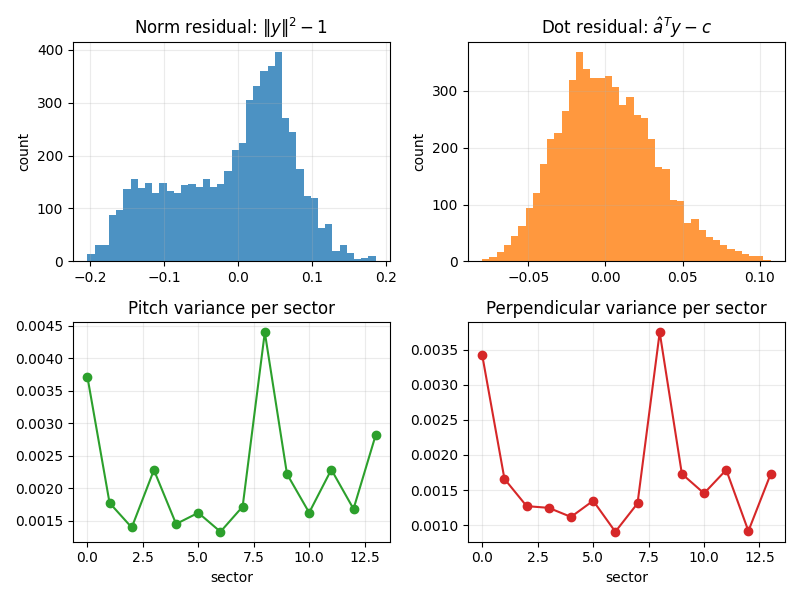

In [40]:
from sector_calibrator import (
    calibrated_sector_objectives,
    plot_diagnostics,
    plot_unit_sphere,
)

fig, axes = plot_diagnostics(calibrator, W_optimized, sectors, result.c)
plt.show()


In [41]:
from sector_calibrator import plot_unit_sphere

figure = plot_unit_sphere(W_optimized, sectors)
figure.show()


accel only
  gyro x scale: 1.1041031284637128
  gyro x bias: -0.055388058962681654
  gyro x correlation: 0.8842280838631997
  gyro x RMSE: 0.18670099512007352
calibrated mag only
  gyro x scale: 0.9506717615958723
  gyro x bias: -0.05528594003916037
  gyro x correlation: 0.7173020260651768
  gyro x RMSE: 0.29562841525311195
accel + calibrated mag
  gyro x scale: 1.0888791771203192
  gyro x bias: -0.0550670820063579
  gyro x correlation: 0.860091211790332
  gyro x RMSE: 0.20675582328026315


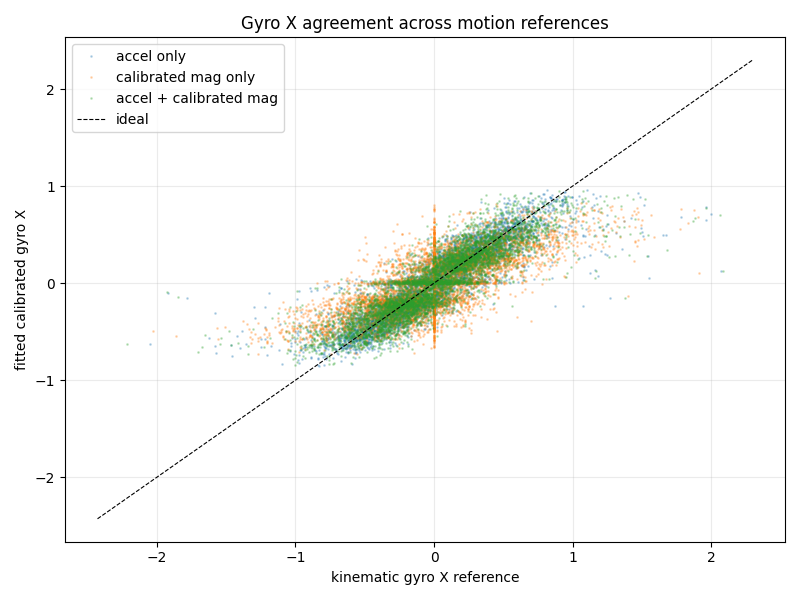

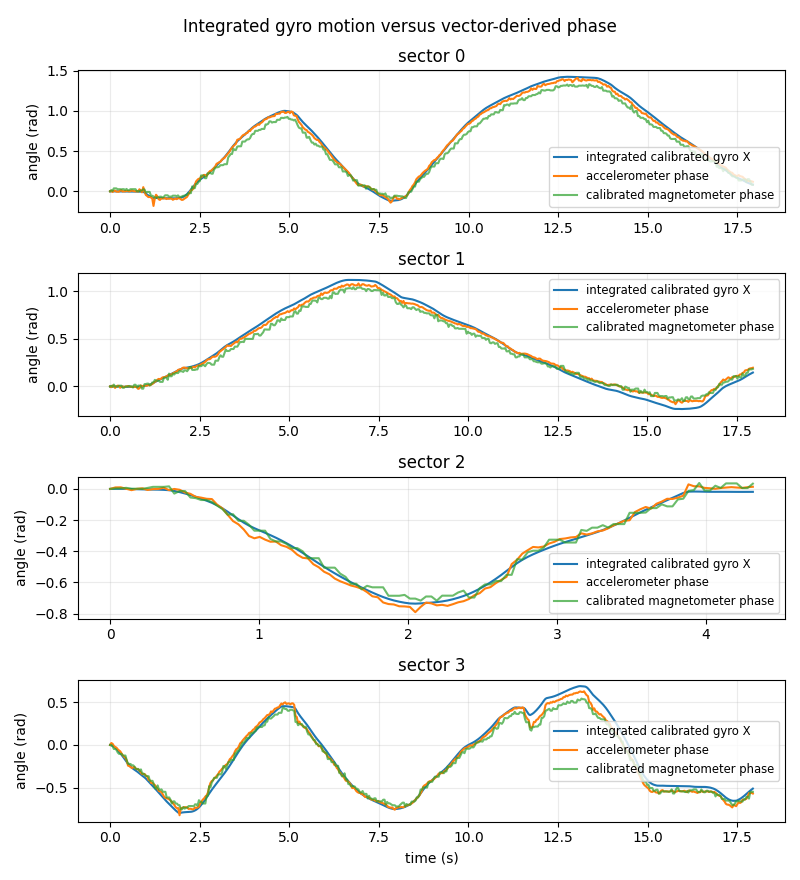

In [42]:
from sector_calibrator import (
    fit_diagonal_bias_gyro,
    plot_gyro_x_comparison,
    plot_integrated_gyro_motion,
)

motion_reports = {
    "accel only": fit_diagonal_bias_gyro(
        sectors,
        W_optimized,
        use_acc=True,
        use_mag=False,
    ),
    "calibrated mag only": fit_diagonal_bias_gyro(
        sectors,
        W_optimized,
        use_acc=False,
        use_mag=True,
    ),
    "accel + calibrated mag": fit_diagonal_bias_gyro(
        sectors,
        W_optimized,
        use_acc=True,
        use_mag=True,
    ),
}

for name, report in motion_reports.items():
    valid = report["valid"]
    print(name)
    print("  gyro x scale:", report["scale"][0])
    print("  gyro x bias:", report["bias"][0])
    print("  gyro x correlation:", report["correlation"][0])
    print("  gyro x RMSE:", np.sqrt(np.mean(report["residual"][valid, 0] ** 2)))

figure, axis = plot_gyro_x_comparison(motion_reports)
plt.show()

# Integrate calibrated gyro X over N samples and compare accumulated phase.
N = 500
plot_integrated_gyro_motion(
    W_optimized,
    sectors,
    motion_reports["accel + calibrated mag"],
    N=N,
    max_sectors=4,
)
plt.show()
